In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

PROJECT_ROOT = Path.cwd().parent   
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.get_google_drive_data import load_csv_from_drive
from utils.google_drive_client import get_drive_client
from utils.utils import get_data_split

/Users/zashabenites/miniconda3/envs/490_midterm/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
service = get_drive_client()
df = load_csv_from_drive(service) 

In [3]:
X_train, X_test, y_train, y_test = get_data_split(df)
train_df = pd.concat([X_train, y_train], axis=1)

In [4]:
train_df.head()

,project id,name,url,category,subcategory,location,goal,pledged,funded percentage,backers,funded date,levels,reward levels,updates,comments,duration,target
40825,1914040019,Summit to Sea,http://www.kickstarter.com/projects/lahoffman/...,Art,Illustration,"Stevensville, Mt",8500.0,2034.0,0.239294,37,"Thu, 01 Mar 2012 06:59:00 -0000",10,"$10,$25,$35,$45,$95,$150,$200,$250,$325,$450",5,3,42.59,False
16576,783122916,Tamara Saari Dance,http://www.kickstarter.com/projects/1117453527...,Dance,Dance,"Lower East Side, NY",2000.0,2017.0,1.008555,36,"Thu, 01 Mar 2012 16:22:00 -0000",6,"$10,$25,$50,$100,$150,$250",6,0,31.60,True
5060,240036276,Four Clowns 2011 National Tour,http://www.kickstarter.com/projects/506558983/...,Theater,Theater,"Los Angeles, CA",5000.0,5210.0,1.042000,48,"Tue, 05 Jul 2011 03:59:00 -0000",7,"$10,$25,$50,$100,$200,$500,$1,000",3,0,40.99,True
47,2353033,&quot;Chased Resignation&quot;,http://www.kickstarter.com/projects/chasedresi...,Film & Video,Film &amp; Video,"Arcadia, CA",20000.0,0.0,0.000000,0,"Tue, 26 Jul 2011 04:00:00 -0000",3,"$20,$100,$1,000",0,0,63.23,False
6455,303755237,People Get Ready: The Parchman Hour is Coming!,http://www.kickstarter.com/projects/90005631/p...,Theater,Theater,"Jackson, MS",7000.0,7100.0,1.014286,104,"Wed, 25 May 2011 02:11:06 -0000",6,"$10,$30,$60,$100,$250,$500",36,11,30.00,True


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29375 entries, 40825 to 2247
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   project id         29375 non-null  int64  
 1   name               29375 non-null  object 
 2   url                29375 non-null  object 
 3   category           29375 non-null  object 
 4   subcategory        29375 non-null  object 
 5   location           28472 non-null  object 
 6   goal               29375 non-null  float64
 7   pledged            29375 non-null  float64
 8   funded percentage  29375 non-null  float64
 9   backers            29375 non-null  int64  
 10  funded date        29375 non-null  object 
 11  levels             29375 non-null  int64  
 12  reward levels      29335 non-null  object 
 13  updates            29375 non-null  int64  
 14  comments           29375 non-null  int64  
 15  duration           29375 non-null  float64
 16  target             29375

In [6]:
info = pd.DataFrame({
    "dtype": X_train.dtypes.astype(str),
    "non-null": X_train.notna().sum(),
    "null": X_train.isna().sum(),
    "null %": (X_train.isna().mean() * 100).round(2),
    "unique": X_train.nunique(),
    "example": X_train.iloc[0].astype(str).str.slice(0, 40),
})
info

,dtype,non-null,null,null %,unique,example
project id,int64,29375,0,0.00,29321,1914040019
name,object,29375,0,0.00,29288,Summit to Sea
url,object,29375,0,0.00,29321,http://www.kickstarter.com/projects/laho
category,object,29375,0,0.00,14,Art
subcategory,object,29375,0,0.00,51,Illustration
location,object,28472,903,3.07,3682,"Stevensville, Mt"
goal,float64,29375,0,0.00,1340,8500.0
pledged,float64,29375,0,0.00,8740,2034.0
funded percentage,float64,29375,0,0.00,15153,0.239294118
backers,int64,29375,0,0.00,795,37


In [7]:
train_df.describe()

,project id,goal,pledged,funded percentage,backers,levels,updates,comments,duration
count,2.937500e+04,2.937500e+04,2.937500e+04,29375.000000,29375.000000,29375.000000,29375.000000,29375.000000,29375.000000
mean,1.077376e+09,9.454898e+03,5.292068e+03,1.556393,73.304102,7.948357,4.308289,8.625260,40.174240
std,6.217019e+08,3.986794e+04,6.906815e+04,60.919587,812.774143,4.133787,6.550769,184.864453,17.775351
min,3.940900e+04,1.000000e-02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,5.394866e+08,1.600000e+03,2.200000e+02,0.051000,5.000000,5.000000,0.000000,0.000000,30.000000
50%,1.071316e+09,4.000000e+03,1.447000e+03,1.005200,24.000000,7.000000,2.000000,1.000000,32.040000
75%,1.620217e+09,8.500000e+03,4.354500e+03,1.130879,61.000000,10.000000,6.000000,3.000000,48.940000
max,2.147460e+09,3.500000e+06,1.026684e+07,10000.000000,87142.000000,74.000000,142.000000,19311.000000,91.960000


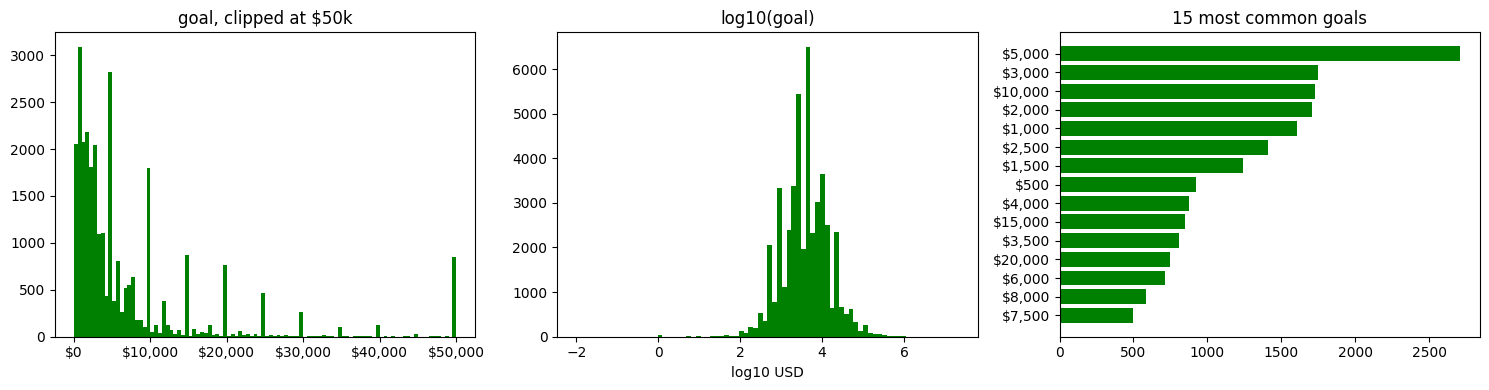

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(X_train["goal"].clip(upper=50_000), bins=100, color='green')
axes[0].set_title("goal, clipped at $50k"); axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].hist(np.log10(df["goal"]), bins=80, color='green')
axes[1].set_title("log10(goal)"); axes[1].set_xlabel("log10 USD")
top = X_train["goal"].value_counts().head(15)
axes[2].barh([f"${int(v):,}" for v in top.index][::-1], top.values[::-1], color='green')
axes[2].set_title("15 most common goals")
plt.tight_layout()

campaigns with zero pledged: 2,412  (8.2%)
campaigns with zero backers: 2,413
median pledge per backer: $55   mean: $73


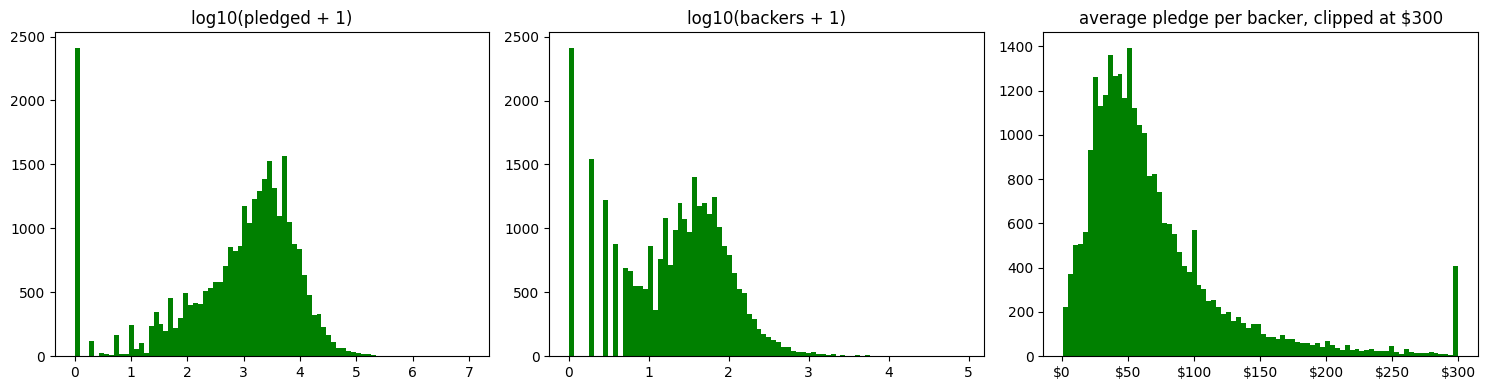

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(np.log10(X_train["pledged"].fillna(0) + 1), bins=80, color='green')
axes[0].set_title("log10(pledged + 1)")
axes[1].hist(np.log10(X_train["backers"] + 1), bins=80, color='green')
axes[1].set_title("log10(backers + 1)")
avg = (X_train["pledged"] / X_train["backers"]).replace([np.inf, -np.inf], np.nan).dropna()
axes[2].hist(avg.clip(upper=300), bins=80, color='green')
axes[2].set_title("average pledge per backer, clipped at $300"); axes[2].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()

print(f"campaigns with zero pledged: {(X_train['pledged'] == 0).sum():,}  ({(X_train['pledged'] == 0).mean():.1%})")
print(f"campaigns with zero backers: {(X_train['backers'] == 0).sum():,}")
print(f"median pledge per backer: ${avg.median():.0f}   mean: ${avg.mean():.0f}")

exactly 30 days: 29.4%    exactly 60: 10.2%
min 1.0  max 91.96  median 32.04


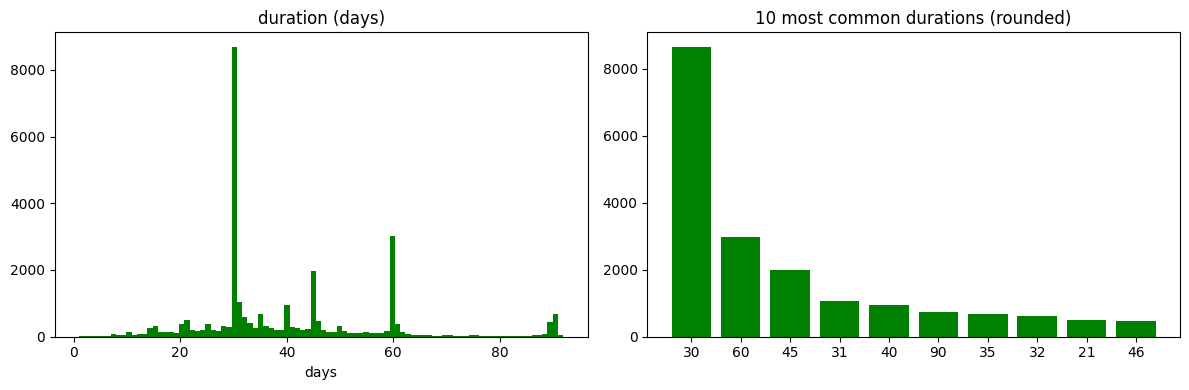

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train["duration"], bins=92, color='green')
axes[0].set_title("duration (days)"); axes[0].set_xlabel("days")
d = X_train["duration"].round().value_counts().head(10)
axes[1].bar(d.index.astype(int).astype(str), d.values, color='green')
axes[1].set_title("10 most common durations (rounded)")
plt.tight_layout()
print(f"exactly 30 days: {(X_train['duration'].round() == 30).mean():.1%}    exactly 60: {(X_train['duration'].round() == 60).mean():.1%}")
print(f"min {X_train['duration'].min()}  max {X_train['duration'].max()}  median {X_train['duration'].median()}")

between 0.5× and 0.95×: 1.4% of campaigns
between 1.00× and 1.10×: 25.8% of campaigns
exactly 1.00×: 628


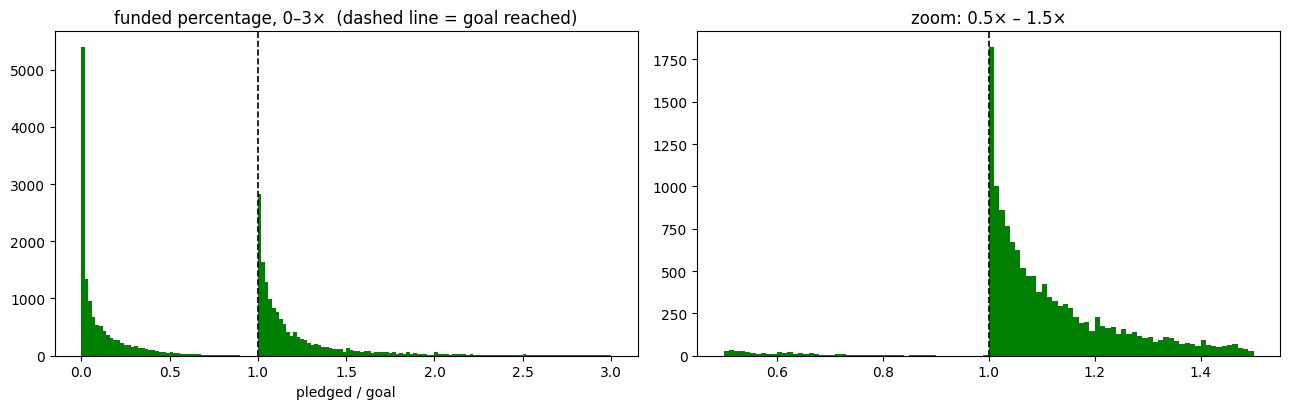

In [11]:
fp = X_train["funded percentage"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].hist(fp[fp <= 3], bins=150, color='green')
axes[0].axvline(1.0, color="k", ls="--", lw=1.2)
axes[0].set_title("funded percentage, 0–3×  (dashed line = goal reached)")
axes[0].set_xlabel("pledged / goal")
axes[1].hist(fp[(fp > 0.5) & (fp < 1.5)], bins=100, color='green')
axes[1].axvline(1.0, color="k", ls="--", lw=1.2)
axes[1].set_title("zoom: 0.5× – 1.5×")
plt.tight_layout()
print(f"between 0.5× and 0.95×: {((fp > 0.5) & (fp < 0.95)).mean():.1%} of campaigns")
print(f"between 1.00× and 1.10×: {((fp >= 1.0) & (fp < 1.10)).mean():.1%} of campaigns")
print(f"exactly 1.00×: {(fp == 1.0).sum()}")

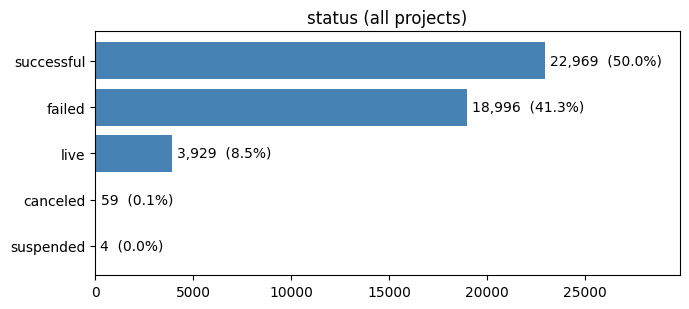

In [12]:
order = ["successful", "failed", "live", "canceled", "suspended"]
st = df["status"].value_counts().reindex(order, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(st.index[::-1], st.values[::-1], color="steelblue")
for i, v in enumerate(st.values[::-1]):
    ax.text(v + st.max() * 0.01, i, f"{v:,}  ({v/len(df):.1%})", va="center")
ax.set_xlim(0, st.max() * 1.3)
ax.set_title("status (all projects)")
plt.tight_layout()